In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv("netflix_titles.csv")

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(df.head())

Rows: 8807
Columns: 12
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  Sep

In [4]:
# -------------------------------
# Missing Values
# -------------------------------
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
df['director'] = df['director'].fillna("Not Available")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna("Not Rated")

In [6]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [7]:
# -------------------------------
# Convert Date Column
# -------------------------------
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [8]:
# -------------------------------
# Clean Text Columns
# -------------------------------
df['type'] = df['type'].str.lower()
df['country'] = df['country'].str.lower()
df['rating'] = df['rating'].str.lower()
df['listed_in'] = df['listed_in'].str.lower()

In [9]:
# -------------------------------
# Extract Duration Values
# -------------------------------
df['duration'] = df['duration'].astype(str)

df['duration_value'] = df['duration'].str.extract(r'(\d+)')
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

df['movie_minutes'] = np.where(df['type'] == 'movie', df['duration_value'], 0)
df['tv_seasons'] = np.where(df['type'] == 'tv show', df['duration_value'], 0)

In [41]:
# Fill all remaining NaN values
df['movie_minutes'] = df['movie_minutes'].fillna(0)
df['tv_seasons'] = df['tv_seasons'].fillna(0)
df['rating_encoded'] = df['rating_encoded'].fillna(0)

In [10]:
# -------------------------------
# Explode Countries
# -------------------------------
df["country"] = df["country"].str.split(",")
df = df.explode("country")
df["country"] = df["country"].str.strip()

In [11]:
# -------------------------------
# Netflix Original or Licensed
# -------------------------------
df["content_origin"] = df["description"].str.lower().apply(
    lambda x: "original" if "netflix" in str(x) else "licensed")
print(df["content_origin"].value_counts())

content_origin
licensed    10841
original        9
Name: count, dtype: int64


In [12]:
# -------------------------------
# Extract Date Features
# -------------------------------
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

In [13]:
df["rating"].value_counts()

rating
tv-ma        3755
tv-14        2406
r            1236
tv-pg        1002
pg-13         769
tv-y7         431
pg            429
tv-y          382
tv-g          244
nr            110
g              62
tv-y7-fv        8
nc-17           5
not rated       4
ur              4
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

In [14]:
df["listed_in"].unique()

array(['documentaries', 'international tv shows, tv dramas, tv mysteries',
       'crime tv shows, international tv shows, tv action & adventure',
       'docuseries, reality tv',
       'international tv shows, romantic tv shows, tv comedies',
       'tv dramas, tv horror, tv mysteries', 'children & family movies',
       'dramas, independent movies, international movies',
       'british tv shows, reality tv', 'comedies, dramas',
       'crime tv shows, docuseries, international tv shows',
       'dramas, international movies',
       'children & family movies, comedies',
       'british tv shows, crime tv shows, docuseries',
       'tv comedies, tv dramas', 'documentaries, international movies',
       'crime tv shows, spanish-language tv shows, tv dramas',
       'thrillers',
       'international tv shows, spanish-language tv shows, tv action & adventure',
       'international tv shows, tv action & adventure, tv dramas',
       'comedies, international movies',
       'comedies, 

In [15]:
df["listed_in"] = df["listed_in"].str.lower().str.strip()
df["listed_in"] = df["listed_in"].str.split(",")
df = df.explode("listed_in")
df["listed_in"] = df["listed_in"].str.strip()

In [16]:
df['listed_in'].value_counts()

listed_in
international movies            3513
dramas                          3202
comedies                        1981
international tv shows          1465
action & adventure              1182
documentaries                   1118
independent movies              1040
tv dramas                        852
children & family movies         845
thrillers                        806
romantic movies                  722
tv comedies                      630
kids' tv                         596
crime tv shows                   541
horror movies                    458
docuseries                       436
music & musicals                 429
romantic tv shows                384
sci-fi & fantasy                 380
stand-up comedy                  344
british tv shows                 306
reality tv                       270
sports movies                    265
tv action & adventure            204
spanish-language tv shows        202
anime series                     192
korean tv shows             

In [17]:
print(df["duration"])

0          90 min
1       2 Seasons
1       2 Seasons
1       2 Seasons
2        1 Season
          ...    
8805       88 min
8805       88 min
8806      111 min
8806      111 min
8806      111 min
Name: duration, Length: 23764, dtype: object


In [18]:
df["duration_minutes"] = df["duration"].str.extract(r"(\d+) min")
df["duration_seasons"] = df["duration"].str.extract(r"(\d+) Season")
df["duration_minutes"] = df["duration_minutes"].fillna("not available")
df["duration_seasons"] = df["duration_seasons"].fillna("not available")

In [19]:
df=df.drop("duration",axis=1)

In [20]:
df.isnull().any()

show_id             False
type                False
title               False
director            False
cast                False
country             False
date_added           True
release_year        False
rating              False
listed_in           False
description         False
duration_value       True
movie_minutes        True
tv_seasons          False
content_origin      False
year_added           True
month_added          True
duration_minutes    False
duration_seasons    False
dtype: bool

In [21]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,movie_minutes,tv_seasons,content_origin,year_added,month_added,duration_minutes,duration_seasons
0,s1,movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,pg-13,documentaries,"As her father nears the end of his life, filmm...",90.0,90.0,0.0,licensed,2021.0,9.0,90,not available


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23764 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           23764 non-null  object        
 1   type              23764 non-null  object        
 2   title             23764 non-null  object        
 3   director          23764 non-null  object        
 4   cast              23764 non-null  object        
 5   country           23764 non-null  object        
 6   date_added        23536 non-null  datetime64[ns]
 7   release_year      23764 non-null  int64         
 8   rating            23764 non-null  object        
 9   listed_in         23764 non-null  object        
 10  description       23764 non-null  object        
 11  duration_value    23761 non-null  float64       
 12  movie_minutes     23761 non-null  float64       
 13  tv_seasons        23764 non-null  float64       
 14  content_origin    23764 non-

In [23]:
# ---------------------------------
# Country Analysis
# ---------------------------------
# Some rows have multiple countries separated by commas
df['country'] = df['country'].fillna("Unknown")
df['country'] = df['country'].str.split(',')
df_country = df.explode('country')
df_country['country'] = df_country['country'].str.strip()
top_countries = df_country['country'].value_counts().head(10)
print(top_countries)

country
united states     6780
india             2804
united kingdom    1783
unknown           1722
france             916
canada             877
japan              733
south korea        632
spain              591
germany            511
Name: count, dtype: int64


In [24]:
# ============================================
# Feature Engineering
df['cast_count'] = df['cast'].apply(lambda x: 0 if x=="Not Available" else len(str(x).split(',')))
df['genre_count'] = df['listed_in'].apply(lambda x: len(str(x).split(',')))
df['country_count'] = df['country'].apply(lambda x: len(str(x).split(',')))
df['content_age'] = df['year_added'] - df['release_year']
df['title_length'] = df['title'].apply(len)

In [35]:
def extract_seasons(x):
    try:
        if 'season' in str(x).lower():
            return int(str(x).split()[0])
    except:
        return np.nan
if 'duration' in df.columns:
    df['movie_minutes'] = df['duration'].apply(extract_minutes)
    df['tv_seasons'] = df['duration'].apply(extract_seasons)

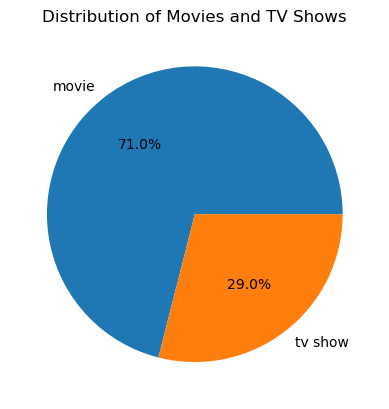

In [25]:
# -------------------------------
# Visualization
# -------------------------------
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Movies and TV Shows")
plt.ylabel("")
plt.show()

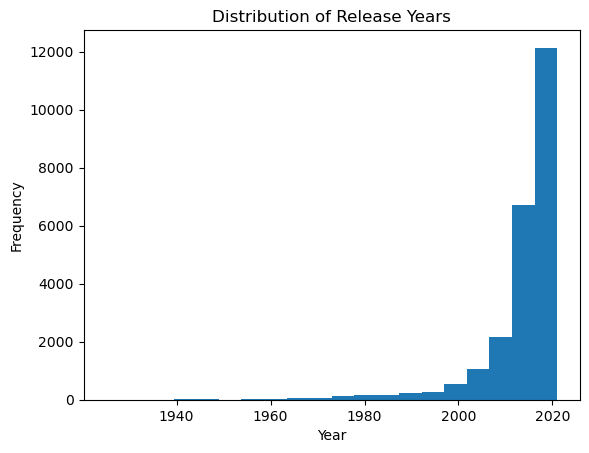

In [26]:
plt.hist(df["release_year"], bins=20)
plt.title("Distribution of Release Years")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

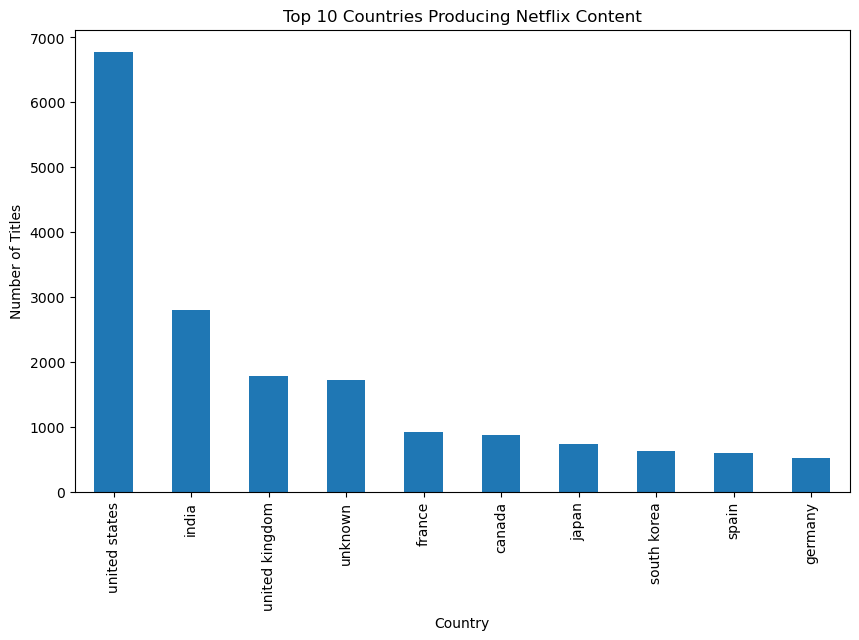

In [27]:
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

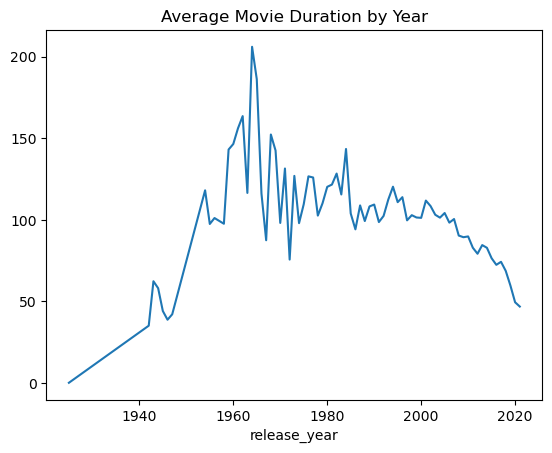

In [28]:
avg_duration = df.groupby("release_year")["movie_minutes"].mean()
avg_duration.plot()
plt.title("Average Movie Duration by Year")
plt.show()

release_year
1925    1
1942    4
1943    4
1944    8
1945    7
Name: count, dtype: int64


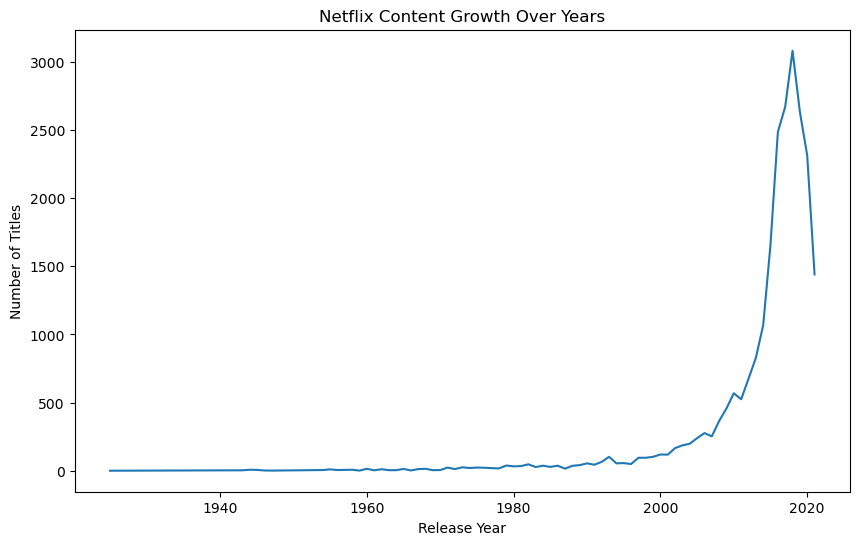

In [29]:
# ---------------------------------
# Netflix Content Growth Over Years
# ---------------------------------
content_growth = df['release_year'].value_counts().sort_index()
print(content_growth.head())
plt.figure(figsize=(10,6))
plt.plot(content_growth.index, content_growth.values)
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

type        movie  tv show
year_added                
2008.0        3.0      1.0
2009.0        3.0      NaN
2010.0        2.0      NaN
2011.0       29.0      NaN
2012.0        5.0      NaN


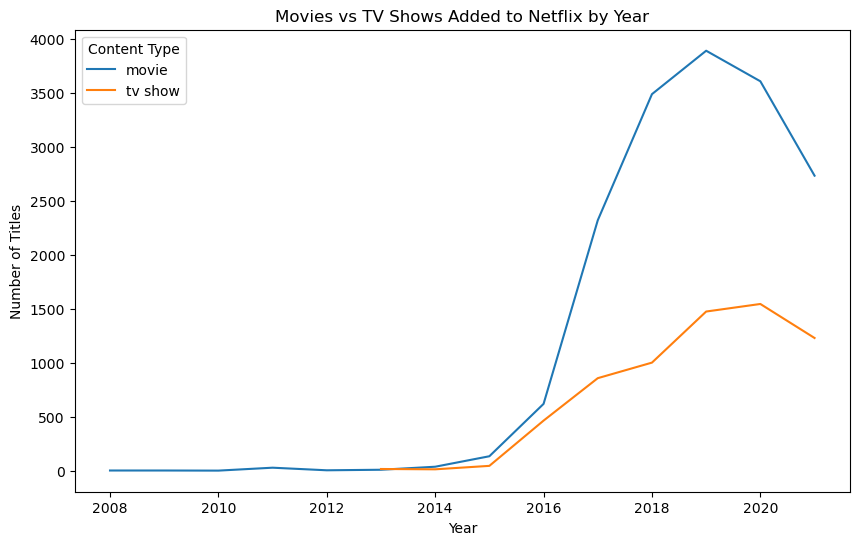

In [30]:
# ---------------------------------
# Movies vs TV Shows Growth by Year
# ---------------------------------
# Extract year from date_added
df['year_added'] = df['date_added'].dt.year
# Group by year and type
content_by_year = df.groupby(['year_added', 'type']).size().unstack()
print(content_by_year.head())
# Plot
content_by_year.plot(kind='line', figsize=(10,6))
plt.title("Movies vs TV Shows Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.show()

In [31]:
# ============================================
# 12. Classification Model
# ============================================
features = [
'release_year',
'movie_minutes',
'tv_seasons',
'cast_count',
'genre_count',
'country_count',
'content_age',
'title_length']
X = df[features].fillna(0)
y = df['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
model = DecisionTreeClassifier(max_depth=6)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix
[[4212    0]
 [   0 1729]]


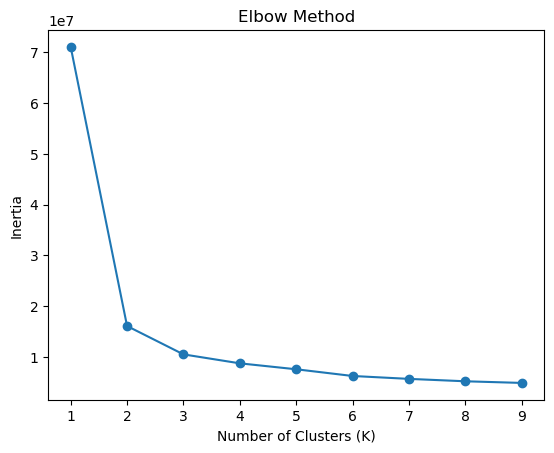

In [34]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

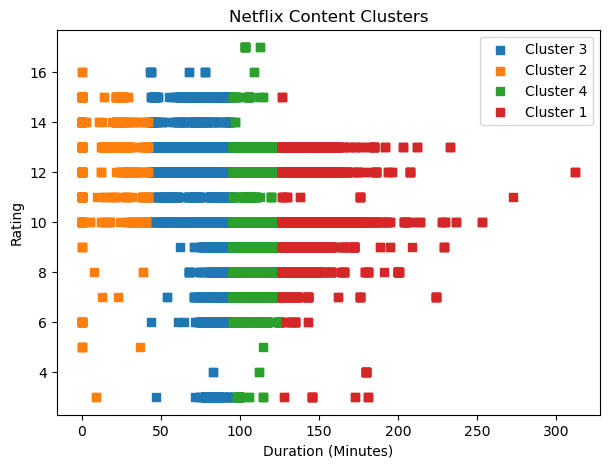

In [32]:
# Encode rating
le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'].astype(str))
cluster_features = df[['movie_minutes','tv_seasons','rating_encoded']].fillna(0)
kmeans = KMeans(n_clusters=4, random_state=1)
# Predict clusters
df['cluster'] = kmeans.fit_predict(cluster_features)
df['cluster_name'] = df['cluster'].apply(lambda x: f"Cluster {x+1}")
plt.figure(figsize=(7,5))

for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    
    plt.scatter(subset['movie_minutes'],
                subset['rating_encoded'],
                marker='s',
                label=f"Cluster {cluster+1}")

plt.title("Netflix Content Clusters")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Rating")
plt.legend()
plt.show()

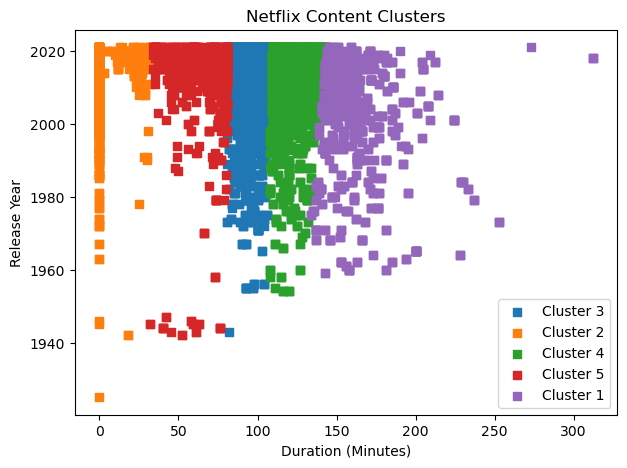

In [33]:
le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'].astype(str))
cluster_features = df[['release_year','movie_minutes','rating_encoded']].fillna(0)
kmeans = KMeans(n_clusters=5, random_state=1)
df['cluster'] = kmeans.fit_predict(cluster_features)
df['cluster_name'] = df['cluster'].apply(lambda x: f"Cluster {x+1}")
plt.figure(figsize=(7,5))
for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['movie_minutes'],
                subset['release_year'],
                marker='s',
                label=f"Cluster {cluster+1}")
plt.title("Netflix Content Clusters")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Release Year")

plt.legend()
plt.show()

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

X_cls = df[['movie_minutes','tv_seasons','rating_encoded']]
y_cls = df['rating_encoded']
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)
print("Logistic Regression Report:")
print(classification_report(y_test, log_preds))

Logistic Regression Report:
              precision    recall  f1-score   support

           3       0.90      1.00      0.95        27
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         2
           6       0.67      0.07      0.13        54
           7       0.77      0.97      0.86       177
           8       0.99      1.00      1.00       303
           9       1.00      1.00      1.00       474
          10       0.99      1.00      1.00      1186
          11       0.00      0.00      0.00        93
          12       0.95      1.00      0.98      1724
          13       0.95      1.00      0.97       462
          14       1.00      0.77      0.87       112
          15       0.96      1.00      0.98       130
          16       0.00      0.00      0.00         4
          17       0.00      0.00      0.00         2

    accuracy                           0.96      4753
   macro avg       0.61      0.59      0.58      475

D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
